# ============================================================
# AI PROTOTYPE: CUSTOMER SUPPORT TICKET CLASSIFICATION
# ============================================================

# Install first:
# pip install transformers torch



In [ ]:
import gradio as gr
from transformers import pipeline

# ------------------------------------------------------------
# 1. Load AI Model
# ------------------------------------------------------------


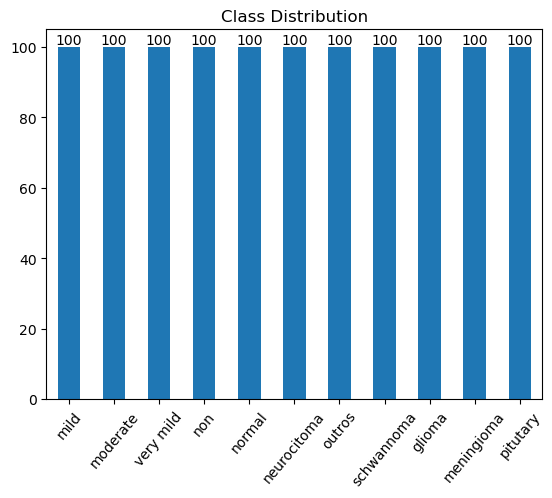

In [2]:
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

# ------------------------------------------------------------
# 2. Define Categories
# ------------------------------------------------------------

In [3]:
categories = [
    "Billing",
    "Technical Issue",
    "Account Access",
    "General Inquiry"
]

1 Mild_Demented: 1.0
2 Moderate_Demented: 1.0
3 Non_Demented: 1.0
4 Very_Mild_Demented: 1.0
5 normal: 1.0
6 neurocitoma: 1.0
7 outros: 1.0
8 schwannoma: 1.0
9 glioma: 1.0
10 meningioma: 1.0
11 pitutary: 1.0


{0: 1.0,
 1: 1.0,
 2: 1.0,
 3: 1.0,
 4: 1.0,
 5: 1.0,
 6: 1.0,
 7: 1.0,
 8: 1.0,
 9: 1.0,
 10: 1.0}

# ------------------------------------------------------------
# 3. Classification Function
# ------------------------------------------------------------


In [4]:
def classify_ticket(message):

    result = classifier(
        message,
        candidate_labels=categories
    )

    predicted_category = result["labels"][0]
    confidence = result["scores"][0]

    return predicted_category, confidence

C:\Users\Kamat\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


# ------------------------------------------------------------
# 4. Example Inputs
# ------------------------------------------------------------


In [5]:
example_tickets = [
    "Why was I charged twice for my subscription?",
    
    "The application crashes whenever I upload a file.",
    
    "I forgot my password and cannot log into my account.",
    
    "What are your customer support hours?"
]

,Filepath,Label
0,1100(350x350x46)\Alzheimer MildDemented\Alzhei...,Alzheimer MildDemented
1,1100(350x350x46)\Alzheimer MildDemented\Alzhei...,Alzheimer MildDemented
2,1100(350x350x46)\Alzheimer MildDemented\Alzhei...,Alzheimer MildDemented
3,1100(350x350x46)\Alzheimer MildDemented\Alzhei...,Alzheimer MildDemented
4,1100(350x350x46)\Alzheimer MildDemented\Alzhei...,Alzheimer MildDemented
...,...,...
1095,1100(350x350x46)\Schwannoma Tumor\schwannoma (...,Schwannoma Tumor
1096,1100(350x350x46)\Schwannoma Tumor\schwannoma (...,Schwannoma Tumor
1097,1100(350x350x46)\Schwannoma Tumor\schwannoma (...,Schwannoma Tumor
1098,1100(350x350x46)\Schwannoma Tumor\schwannoma (...,Schwannoma Tumor


# ------------------------------------------------------------
# 5. Generate Predictions
# ------------------------------------------------------------


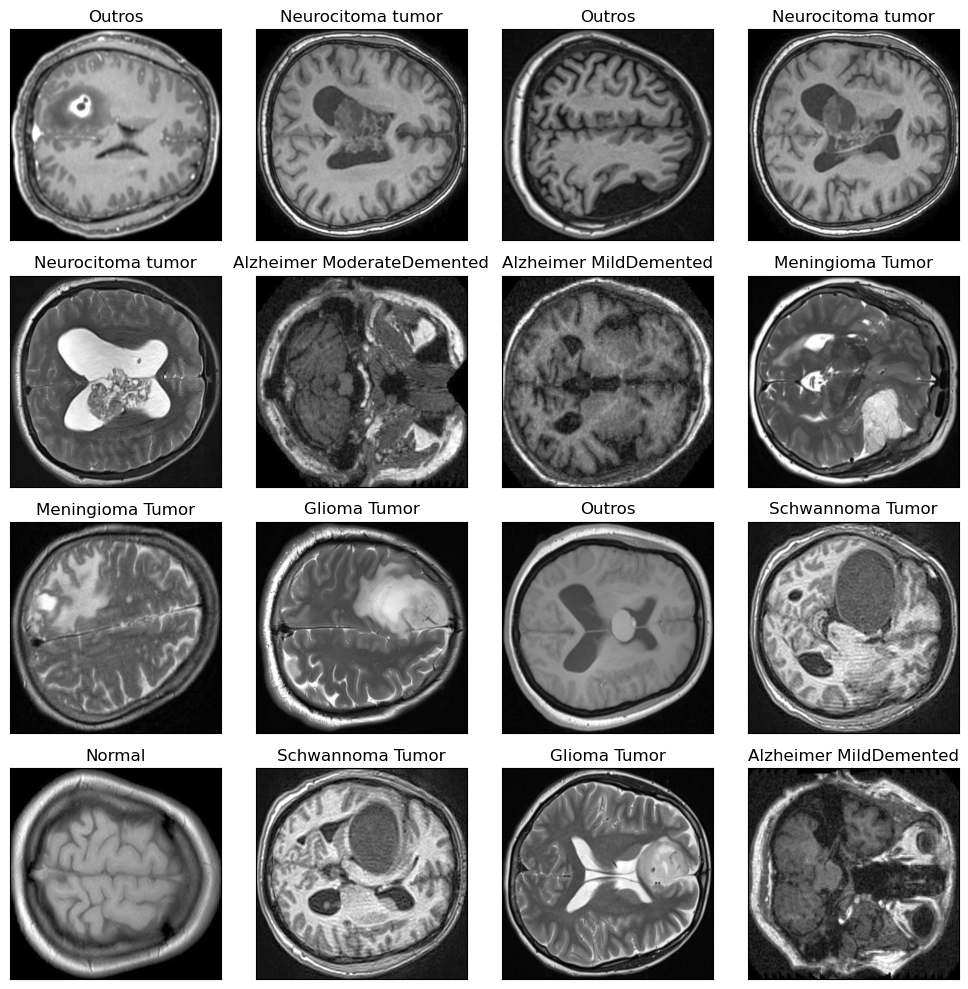

In [6]:
print("=" * 60)
print("CUSTOMER SUPPORT AI CLASSIFICATION PROTOTYPE")
print("=" * 60)

for ticket in example_tickets:

    category, confidence = classify_ticket(ticket)

    print("\nInput:")
    print(ticket)

    print("Output:")
    print("Category:", category)
    print("Confidence:", f"{confidence:.2%}")

# ------------------------------------------------------------
# 6. Interactive Mode
# ------------------------------------------------------------


Normal


100%|██████████| 100/100 [00:00<00:00, 1171.43it/s]


Alzheimer MildDemented


100%|██████████| 100/100 [00:00<00:00, 1306.36it/s]


Alzheimer ModerateDemented


...

Meningioma Tumor


100%|██████████| 100/100 [00:00<00:00, 1209.53it/s]


Pituitary Tumor


100%|██████████| 100/100 [00:00<00:00, 1174.81it/s]


Train images: 990
Test images: 110


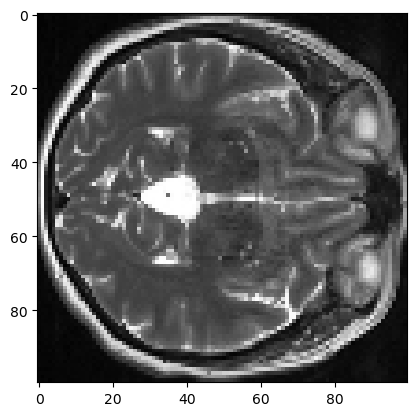

In [7]:
print("\n" + "=" * 60)
print("INTERACTIVE MODE")
print("=" * 60)

while True:

    message = input(
        "\nEnter a customer support message "
        "(type 'exit' to stop): "
    )

    if message.lower() == "exit":
        print("Prototype terminated.")
        break

    category, confidence = classify_ticket(message)

    print("\nAI Output")
    print("-" * 30)
    print("Predicted Category:", category)
    print("Confidence:", f"{confidence:.2%}")

# ------------------------------------------------------------
# 7. Frontend Interface via gradio
# ------------------------------------------------------------

In [8]:
demo = gr.Interface(
    fn=classify_ticket,
    inputs=gr.Textbox(
        label="Customer Support Message",
        placeholder="Example: I forgot my password..."
    ),
    outputs=gr.Textbox(
        label="AI Classification"
    ),
    title="AI Customer Support Ticket Classifier",
    description=(
        "Enter a customer-support message and "
        "the AI will classify it into one of four categories."
    )
)

demo.launch()

Train images: 990
Test images: 110
Test images: 1100
